# Ethnicity Detection with PyTorch


In [1]:
# ==========================
# Import Required Libraries
# ==========================

from copy import deepcopy
from pathlib import Path
import random
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from torch import nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

PyTorch version: 2.6.0+cu126
Device: cuda


In [2]:
# ============================================
# Dataset and output paths
# ============================================

cwd = Path.cwd().resolve()
workspace_candidates = [cwd, *cwd.parents]
WORKSPACE_ROOT = next(
    path for path in workspace_candidates
    if (path / "project" / "src" / "data.py").exists()
)
if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))

from project.src.data import load_metadata

project_candidates = [cwd / "project", cwd, *[parent / "project" for parent in cwd.parents]]
PROJECT_ROOT = next(
    path for path in project_candidates
    if (path / "data" / "processed" / "utkface_metadata.csv").exists()
)
METADATA_PATH = PROJECT_ROOT / "data" / "processed" / "utkface_metadata.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "ethnicity_pytorch"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

metadata = load_metadata(METADATA_PATH)

print("Project root:", PROJECT_ROOT)
print("Metadata path:", METADATA_PATH)
print("Number of images:", len(metadata))
print("Split counts:")
display(metadata["split"].value_counts().reindex(["train", "val", "test"]).to_frame("images"))

Project root: D:\work\extra\diversification\project
Metadata path: D:\work\extra\diversification\project\data\processed\utkface_metadata.csv
Number of images: 23705
Split counts:


,images
split,
train,16593
val,3556
test,3556


,Original Class,Count
0,White,10078
1,Black,4526
2,Asian,3434
3,Indian,3975
4,Others,1692


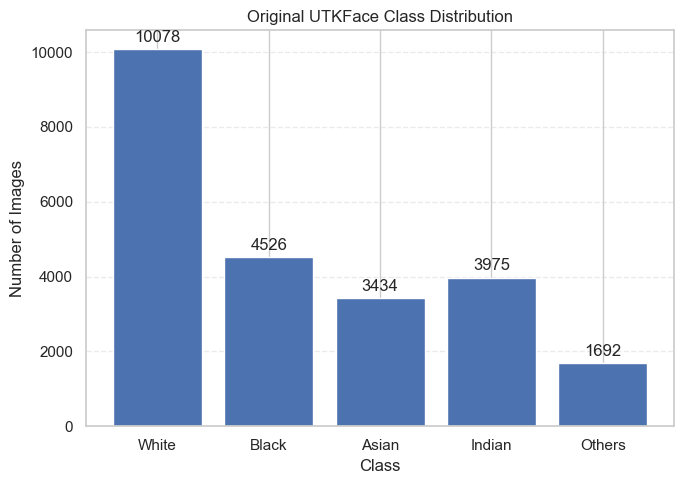

In [3]:
# ============================================
# Original Class Distribution
# ============================================

ORIGINAL_MAPPING = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Others",
}

original_counts = (
    metadata["race_id"]
    .astype(int)
    .map(ORIGINAL_MAPPING)
    .value_counts()
    .reindex(ORIGINAL_MAPPING.values(), fill_value=0)
)
distribution = original_counts.rename_axis("Original Class").reset_index(name="Count")
display(distribution)

plt.figure(figsize=(7, 5))
bars = plt.bar(distribution["Original Class"], distribution["Count"])
plt.title("Original UTKFace Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

,Merged Group,Count
0,USA,10078
1,Africa,4526
2,India,3975
3,Other,5126


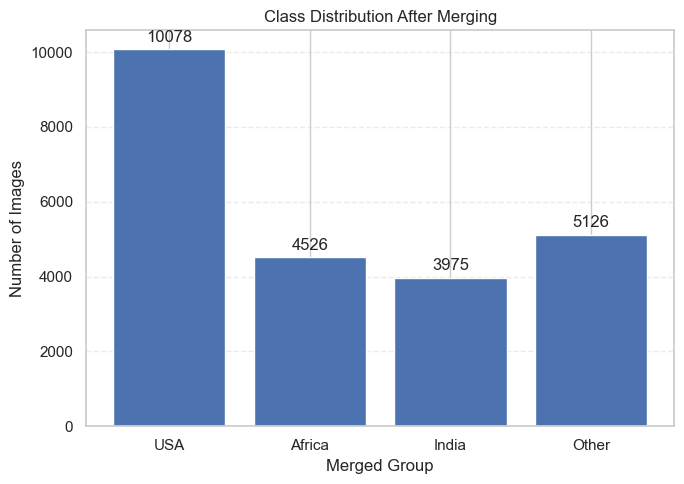

In [4]:
# ============================================
# Merge Classes
# ============================================

# Same mapping as the supplied TensorFlow/Keras notebook.
MERGED_NAME_BY_RACE_ID = {
    0: "USA",      # White
    1: "Africa",   # Black
    2: "Other",    # Asian
    3: "India",    # Indian
    4: "Other",    # Others
}
CLASS_NAMES = ["USA", "Africa", "India", "Other"]
CLASS_TO_ID = {name: index for index, name in enumerate(CLASS_NAMES)}
LABEL_BY_RACE_ID = {
    race_id: CLASS_TO_ID[class_name]
    for race_id, class_name in MERGED_NAME_BY_RACE_ID.items()
}

metadata = metadata.copy()
metadata["merged_class"] = metadata["race_id"].astype(int).map(MERGED_NAME_BY_RACE_ID)
metadata["target"] = metadata["race_id"].astype(int).map(LABEL_BY_RACE_ID).astype(int)

merged_counts = (
    metadata["merged_class"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)
merged_distribution = merged_counts.rename_axis("Merged Group").reset_index(name="Count")
display(merged_distribution)

plt.figure(figsize=(7, 5))
bars = plt.bar(merged_distribution["Merged Group"], merged_distribution["Count"])
plt.title("Class Distribution After Merging")
plt.xlabel("Merged Group")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

,filename,image_path,age,gender,race_id,race,merged_class,target,split
0,100_0_0_20170112213500903.jpg.chip.jpg,D:\work\extra\diversification\project\data\UTK...,100,Male,0,White,USA,0,train
1,100_0_0_20170112215240346.jpg.chip.jpg,D:\work\extra\diversification\project\data\UTK...,100,Male,0,White,USA,0,train
2,100_1_0_20170110183726390.jpg.chip.jpg,D:\work\extra\diversification\project\data\UTK...,100,Female,0,White,USA,0,train
3,100_1_0_20170112213001988.jpg.chip.jpg,D:\work\extra\diversification\project\data\UTK...,100,Female,0,White,USA,0,train
4,100_1_0_20170112213303693.jpg.chip.jpg,D:\work\extra\diversification\project\data\UTK...,100,Female,0,White,USA,0,train


Total images: 23,705


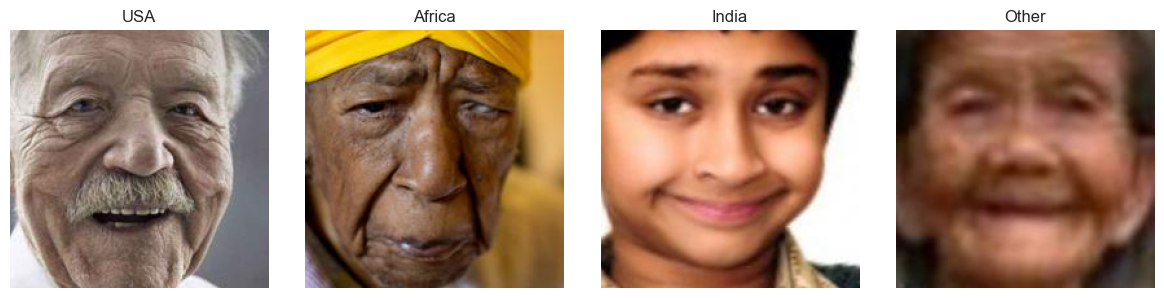

In [5]:
# ============================================
# Extract Labels and Display Sample Images
# ============================================

image_info = metadata[
    ["filename", "image_path", "age", "gender", "race_id", "race", "merged_class", "target", "split"]
].copy()
display(image_info.head())
print(f"Total images: {len(image_info):,}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for axis, class_name in zip(axes, CLASS_NAMES):
    row = image_info[image_info["merged_class"] == class_name].iloc[0]
    with Image.open(row["image_path"]) as source:
        axis.imshow(source.convert("RGB"))
    axis.set_title(class_name)
    axis.axis("off")
plt.tight_layout()
plt.show()

## Data loaders

PyTorch's `CrossEntropyLoss` expects integer class IDs, so one-hot encoding is
not needed. The existing reproducible train/validation/test assignments from
`utkface_metadata.csv` are used rather than creating a new random split.

In [6]:
# ============================================
# Image Dataset and Data Loaders
# ============================================

IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 0  # Safe for Windows and notebook environments.

image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])


class EthnicityDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row["image_path"]) as source:
            image = source.convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        label = torch.tensor(int(row["target"]), dtype=torch.long)
        return image, label


split_frames = {
    split: image_info[image_info["split"] == split].reset_index(drop=True)
    for split in ("train", "val", "test")
}
datasets = {
    split: EthnicityDataset(frame, image_transform)
    for split, frame in split_frames.items()
}

loader_generator = torch.Generator().manual_seed(SEED)
loaders = {
    "train": DataLoader(
        datasets["train"],
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        generator=loader_generator,
    ),
    "val": DataLoader(
        datasets["val"],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
    ),
    "test": DataLoader(
        datasets["test"],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
    ),
}

for split in ("train", "val", "test"):
    print(f"{split.title():5s}: {len(datasets[split]):,} images")

images, labels = next(iter(loaders["train"]))
print("Batch images:", tuple(images.shape))
print("Batch labels:", tuple(labels.shape))

Train: 16,593 images
Val  : 3,556 images
Test : 3,556 images
Batch images: (32, 3, 128, 128)
Batch labels: (32,)


In [7]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    context = torch.enable_grad() if training else torch.inference_mode()
    with context:
        for images, targets in loader:
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, targets)

            if training:
                loss.backward()
                optimizer.step()

            batch_size = targets.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_samples += batch_size

    return {
        "loss": total_loss / total_samples,
        "accuracy": total_correct / total_samples,
    }


def train_model(
    model,
    model_name,
    epochs,
    learning_rate=1e-3,
    early_stopping_patience=None,
    reduce_learning_rate=False,
):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=learning_rate)
    scheduler = (
        ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)
        if reduce_learning_rate else None
    )
    checkpoint_path = OUTPUT_DIR / f"{model_name}.pt"
    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        started = time.perf_counter()
        train_metrics = run_epoch(model, loaders["train"], criterion, optimizer)
        val_metrics = run_epoch(model, loaders["val"], criterion)

        history["loss"].append(train_metrics["loss"])
        history["accuracy"].append(train_metrics["accuracy"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])

        if scheduler is not None:
            scheduler.step(val_metrics["loss"])

        improved = val_metrics["loss"] < best_val_loss
        if improved:
            best_val_loss = val_metrics["loss"]
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
            torch.save(
                {
                    "model_name": model_name,
                    "model_state_dict": best_state,
                    "class_names": CLASS_NAMES,
                    "label_by_race_id": LABEL_BY_RACE_ID,
                    "image_size": IMAGE_SIZE,
                    "best_val_loss": best_val_loss,
                    "epoch": epoch,
                },
                checkpoint_path,
            )
        else:
            epochs_without_improvement += 1

        elapsed = time.perf_counter() - started
        print(
            f"Epoch {epoch:02d}/{epochs} - {elapsed:6.1f}s - "
            f"loss: {train_metrics['loss']:.4f} - "
            f"accuracy: {train_metrics['accuracy']:.4f} - "
            f"val_loss: {val_metrics['loss']:.4f} - "
            f"val_accuracy: {val_metrics['accuracy']:.4f}"
        )

        if (
            early_stopping_patience is not None
            and epochs_without_improvement >= early_stopping_patience
        ):
            print(f"Early stopping at epoch {epoch}.")
            break

    model.load_state_dict(best_state)
    print("Restored best checkpoint:", checkpoint_path)
    return model, history, checkpoint_path


def plot_history(history, model_name):
    epochs = range(1, len(history["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(epochs, history["accuracy"], label="Training Accuracy")
    axes[0].plot(epochs, history["val_accuracy"], label="Validation Accuracy")
    axes[0].set(title=f"{model_name} Accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[0].legend()

    axes[1].plot(epochs, history["loss"], label="Training Loss")
    axes[1].plot(epochs, history["val_loss"], label="Validation Loss")
    axes[1].set(title=f"{model_name} Loss", xlabel="Epoch", ylabel="Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, model_name):
    criterion = nn.CrossEntropyLoss()
    metrics = run_epoch(model, loaders["test"], criterion)
    y_true = []
    y_pred = []

    model.eval()
    with torch.inference_mode():
        for images, targets in loaders["test"]:
            logits = model(images.to(DEVICE, non_blocking=True))
            y_true.extend(targets.numpy().tolist())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())

    print(f"Test Loss     : {metrics['loss']:.4f}")
    print(f"Test Accuracy : {metrics['accuracy'] * 100:.2f}%")
    print()
    print(classification_report(
        y_true,
        y_pred,
        labels=range(len(CLASS_NAMES)),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    ))

    matrix = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)))
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "loss": metrics["loss"],
        "accuracy": metrics["accuracy"],
        "y_true": np.asarray(y_true),
        "y_pred": np.asarray(y_pred),
    }

## Version 1

In [8]:
# ============================================
# Model Creation - Version 1
# ============================================

class EthnicityCNNv1(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 14 * 14, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, images):
        return self.classifier(self.features(images))


model_v1 = EthnicityCNNv1()
print(model_v1)
print(f"Trainable parameters: {sum(p.numel() for p in model_v1.parameters() if p.requires_grad):,}")

EthnicityCNNv1(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=25088, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)
Trainable parameters: 6,517,060


Epoch 01/30 -  153.7s - loss: 1.0225 - accuracy: 0.5799 - val_loss: 0.7666 - val_accuracy: 0.7134
Epoch 02/30 -   25.2s - loss: 0.7753 - accuracy: 0.7049 - val_loss: 0.6798 - val_accuracy: 0.7503
Epoch 03/30 -   25.5s - loss: 0.6872 - accuracy: 0.7427 - val_loss: 0.6231 - val_accuracy: 0.7688
Epoch 04/30 -   25.6s - loss: 0.6279 - accuracy: 0.7658 - val_loss: 0.6028 - val_accuracy: 0.7776
Epoch 05/30 -   25.5s - loss: 0.5845 - accuracy: 0.7868 - val_loss: 0.5688 - val_accuracy: 0.7908
Epoch 06/30 -   25.5s - loss: 0.5455 - accuracy: 0.7959 - val_loss: 0.5655 - val_accuracy: 0.8026
Epoch 07/30 -   25.7s - loss: 0.5014 - accuracy: 0.8173 - val_loss: 0.5485 - val_accuracy: 0.8023
Epoch 08/30 -   25.5s - loss: 0.4707 - accuracy: 0.8262 - val_loss: 0.5451 - val_accuracy: 0.8068
Epoch 09/30 -   25.6s - loss: 0.4329 - accuracy: 0.8364 - val_loss: 0.6077 - val_accuracy: 0.7964
Epoch 10/30 -   25.6s - loss: 0.4011 - accuracy: 0.8508 - val_loss: 0.5566 - val_accuracy: 0.8076
Epoch 11/30 -   25.5

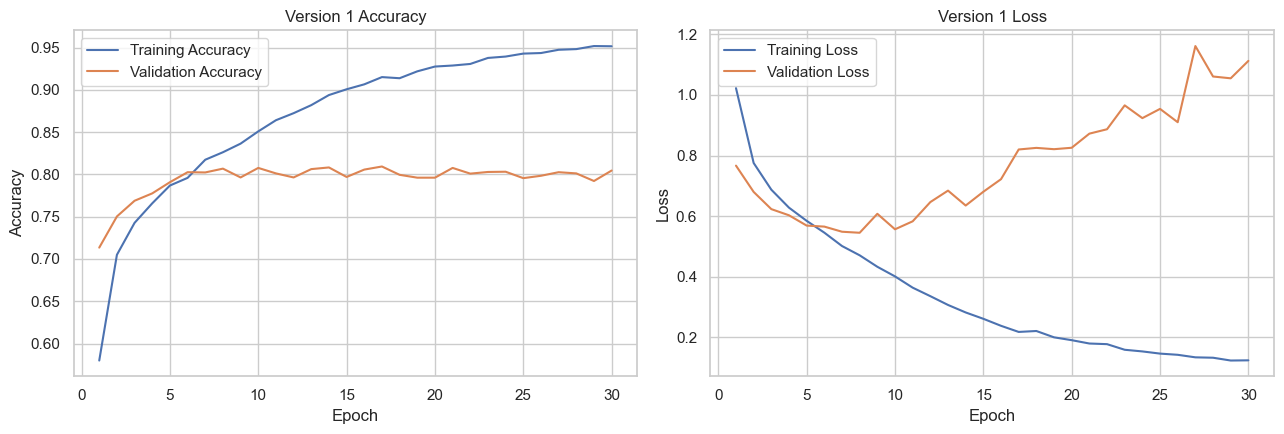

Test Loss     : 0.5659
Test Accuracy : 78.85%

              precision    recall  f1-score   support

         USA     0.8446    0.8340    0.8393      1512
      Africa     0.8426    0.8525    0.8475       678
       India     0.6463    0.7970    0.7137       596
       Other     0.7632    0.6364    0.6941       770

    accuracy                         0.7885      3556
   macro avg     0.7742    0.7800    0.7736      3556
weighted avg     0.7934    0.7885    0.7884      3556



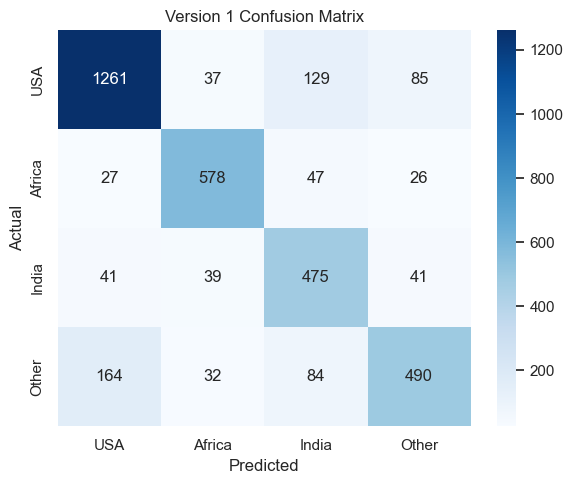

In [9]:
# ============================================
# Train, Plot, and Evaluate Version 1
# ============================================

model_v1, history_v1, checkpoint_v1 = train_model(
    model_v1,
    model_name="ethnicity_model_v1",
    epochs=30,
)
plot_history(history_v1, "Version 1")
results_v1 = evaluate_model(model_v1, "Version 1")

## Version 2

In [10]:
# ============================================
# Model Creation - Version 2
# ============================================

class ConvBatchNormBlock(nn.Sequential):
    def __init__(self, in_channels, out_channels):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )


class EthnicityCNNv2(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            ConvBatchNormBlock(3, 32),
            ConvBatchNormBlock(32, 64),
            ConvBatchNormBlock(64, 128),
            ConvBatchNormBlock(128, 256),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, images):
        return self.classifier(self.features(images))


model_v2 = EthnicityCNNv2()
print(model_v2)
print(f"Trainable parameters: {sum(p.numel() for p in model_v2.parameters() if p.requires_grad):,}")

EthnicityCNNv2(
  (features): Sequential(
    (0): ConvBatchNormBlock(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): ConvBatchNormBlock(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): ConvBatchNormBlock(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )


Epoch 01/50 -   27.6s - loss: 1.2730 - accuracy: 0.4835 - val_loss: 0.9581 - val_accuracy: 0.5689
Epoch 02/50 -   27.0s - loss: 1.0096 - accuracy: 0.5715 - val_loss: 0.8849 - val_accuracy: 0.6485
Epoch 03/50 -   27.0s - loss: 0.9203 - accuracy: 0.6288 - val_loss: 0.7889 - val_accuracy: 0.7039
Epoch 04/50 -   26.9s - loss: 0.8557 - accuracy: 0.6681 - val_loss: 0.7121 - val_accuracy: 0.7393
Epoch 05/50 -   27.0s - loss: 0.8084 - accuracy: 0.6912 - val_loss: 0.6507 - val_accuracy: 0.7792
Epoch 06/50 -   27.0s - loss: 0.7698 - accuracy: 0.7120 - val_loss: 0.6490 - val_accuracy: 0.7750
Epoch 07/50 -   27.0s - loss: 0.7485 - accuracy: 0.7183 - val_loss: 0.6378 - val_accuracy: 0.7767
Epoch 08/50 -   26.9s - loss: 0.7185 - accuracy: 0.7302 - val_loss: 0.6390 - val_accuracy: 0.7846
Epoch 09/50 -   27.0s - loss: 0.6900 - accuracy: 0.7428 - val_loss: 0.5969 - val_accuracy: 0.7964
Epoch 10/50 -   27.0s - loss: 0.6632 - accuracy: 0.7525 - val_loss: 0.6123 - val_accuracy: 0.7964
Epoch 11/50 -   27.0

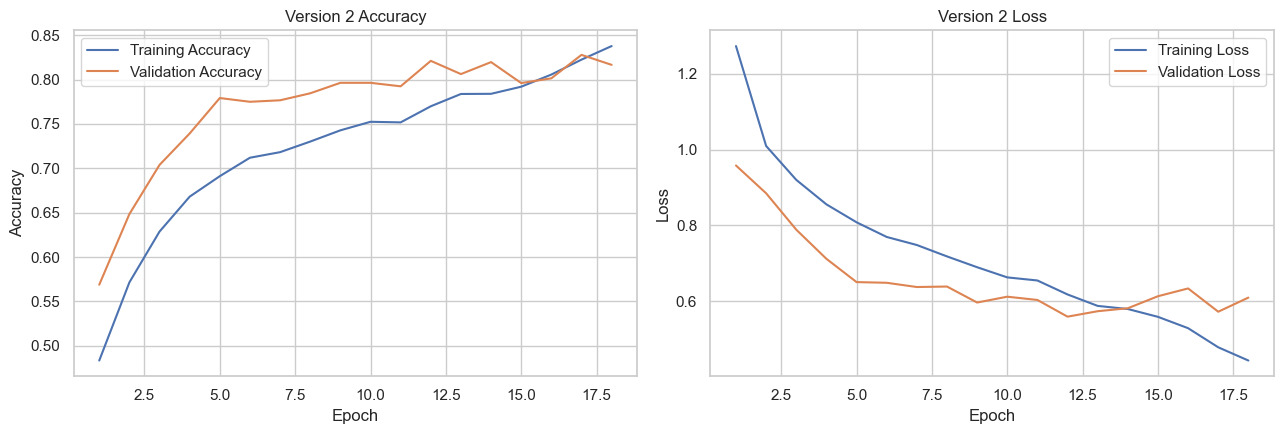

Test Loss     : 0.5751
Test Accuracy : 80.93%

              precision    recall  f1-score   support

         USA     0.8467    0.8770    0.8616      1512
      Africa     0.8656    0.8451    0.8552       678
       India     0.6695    0.8054    0.7312       596
       Other     0.8167    0.6481    0.7227       770

    accuracy                         0.8093      3556
   macro avg     0.7996    0.7939    0.7927      3556
weighted avg     0.8141    0.8093    0.8084      3556



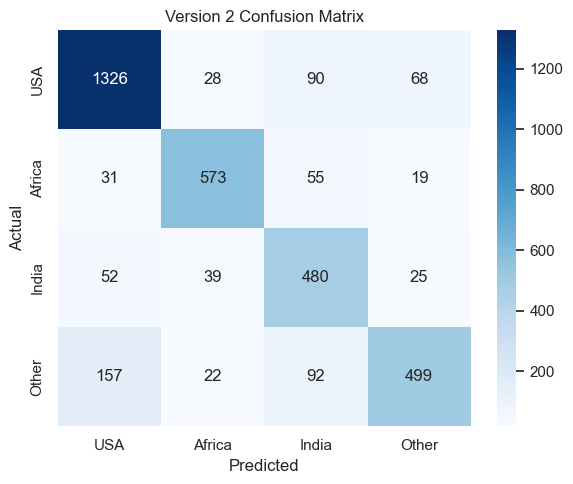

In [11]:
# ============================================
# Train, Plot, and Evaluate Version 2
# ============================================

model_v2, history_v2, checkpoint_v2 = train_model(
    model_v2,
    model_name="ethnicity_model_v2",
    epochs=50,
    early_stopping_patience=6,
    reduce_learning_rate=True,
)
plot_history(history_v2, "Version 2")
results_v2 = evaluate_model(model_v2, "Version 2")

## Version 3

In [12]:
# ============================================
# Model Creation - Version 3
# ============================================

class EthnicityCNNv3(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            ConvBatchNormBlock(3, 32),
            ConvBatchNormBlock(32, 64),
            ConvBatchNormBlock(64, 128),
            ConvBatchNormBlock(128, 256),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, images):
        
        return self.classifier(self.features(images))


model_v3 = EthnicityCNNv3()
print(model_v3)
print(f"Trainable parameters: {sum(p.numel() for p in model_v3.parameters() if p.requires_grad):,}")

EthnicityCNNv3(
  (features): Sequential(
    (0): ConvBatchNormBlock(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): ConvBatchNormBlock(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): ConvBatchNormBlock(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )


Epoch 01/30 -   28.1s - loss: 1.2739 - accuracy: 0.4663 - val_loss: 1.1083 - val_accuracy: 0.5402
Epoch 02/30 -   28.0s - loss: 1.0766 - accuracy: 0.5428 - val_loss: 0.9927 - val_accuracy: 0.6097
Epoch 03/30 -   28.0s - loss: 0.9262 - accuracy: 0.6268 - val_loss: 0.8858 - val_accuracy: 0.6949
Epoch 04/30 -   28.0s - loss: 0.8410 - accuracy: 0.6735 - val_loss: 0.7627 - val_accuracy: 0.7522
Epoch 05/30 -   28.0s - loss: 0.7708 - accuracy: 0.7207 - val_loss: 0.7741 - val_accuracy: 0.7103
Epoch 06/30 -   28.0s - loss: 0.7268 - accuracy: 0.7340 - val_loss: 0.6917 - val_accuracy: 0.7508
Epoch 07/30 -   28.1s - loss: 0.6915 - accuracy: 0.7495 - val_loss: 0.6773 - val_accuracy: 0.7807
Epoch 08/30 -   28.1s - loss: 0.6554 - accuracy: 0.7660 - val_loss: 0.6633 - val_accuracy: 0.7784
Epoch 09/30 -   28.1s - loss: 0.6358 - accuracy: 0.7707 - val_loss: 0.6759 - val_accuracy: 0.7846
Epoch 10/30 -   28.1s - loss: 0.6058 - accuracy: 0.7860 - val_loss: 0.6828 - val_accuracy: 0.7480
Epoch 11/30 -   28.2

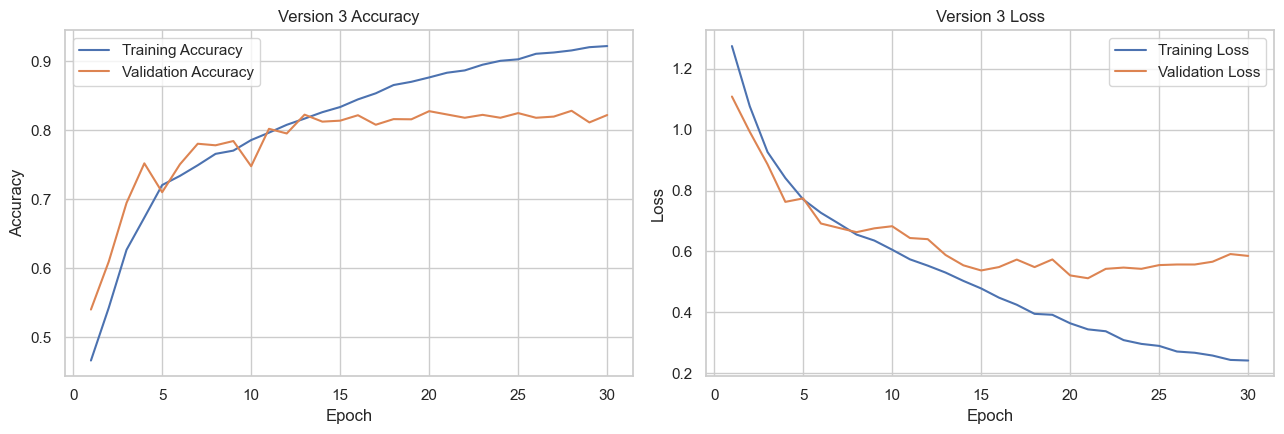

Test Loss     : 0.5424
Test Accuracy : 80.99%

              precision    recall  f1-score   support

         USA     0.8166    0.8955    0.8543      1512
      Africa     0.8815    0.8451    0.8630       678
       India     0.7147    0.7651    0.7391       596
       Other     0.8148    0.6455    0.7203       770

    accuracy                         0.8099      3556
   macro avg     0.8069    0.7878    0.7941      3556
weighted avg     0.8115    0.8099    0.8076      3556



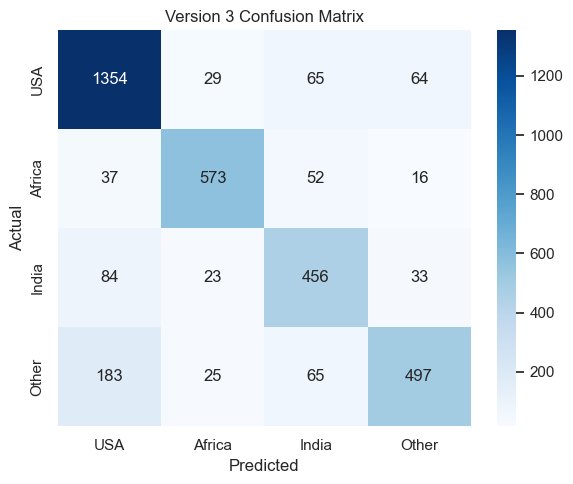

In [13]:
# ============================================
# Train, Plot, and Evaluate Version 3
# ============================================

model_v3, history_v3, checkpoint_v3 = train_model(
    model_v3,
    model_name="ethnicity_model_v3",
    epochs=30,
)
plot_history(history_v3, "Version 3")
results_v3 = evaluate_model(model_v3, "Version 3")

## Compare all three versions

The table uses the untouched test split. Select a model only after all
architecture and training decisions have been finalized; repeatedly choosing
based on test accuracy would leak test-set information.

In [14]:
comparison = pd.DataFrame([
    {
        "model": "Version 1",
        "test_loss": results_v1["loss"],
        "test_accuracy": results_v1["accuracy"],
        "checkpoint": str(checkpoint_v1),
    },
    {
        "model": "Version 2",
        "test_loss": results_v2["loss"],
        "test_accuracy": results_v2["accuracy"],
        "checkpoint": str(checkpoint_v2),
    },
    {
        "model": "Version 3",
        "test_loss": results_v3["loss"],
        "test_accuracy": results_v3["accuracy"],
        "checkpoint": str(checkpoint_v3),
    },
]).sort_values("test_accuracy", ascending=False)

display(comparison.style.format({"test_loss": "{:.4f}", "test_accuracy": "{:.2%}"}))
comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
print("Saved comparison:", OUTPUT_DIR / "model_comparison.csv")

,model,test_loss,test_accuracy,checkpoint
2,Version 3,0.5424,80.99%,D:\work\extra\diversification\project\outputs\ethnicity_pytorch\ethnicity_model_v3.pt
1,Version 2,0.5751,80.93%,D:\work\extra\diversification\project\outputs\ethnicity_pytorch\ethnicity_model_v2.pt
0,Version 1,0.5659,78.85%,D:\work\extra\diversification\project\outputs\ethnicity_pytorch\ethnicity_model_v1.pt


Saved comparison: D:\work\extra\diversification\project\outputs\ethnicity_pytorch\model_comparison.csv
